# Employee Exit Survey Analysis: DETE vs. TAFE
## Practical Data Cleaning, Schema Harmonization, and Attrition Analytics

### Project Overview
This notebook examines exit survey records from two public educational bodies in Queensland, Australia: the Department of Education, Training and Employment (DETE, covering primary and secondary schools) and the Technical and Further Education institute (TAFE, covering vocational education).

### Primary Research Questions
1. Do short-tenure staff leave mainly because of job dissatisfaction, or for other reasons?
2. How does dissatisfaction differ for veteran staff with longer tenure?
3. Do dissatisfaction patterns vary noticeably between DETE and TAFE institutions?
4. What specific factors, such as workload, leadership, or compensation, drive staff departures?

## 1. Environment Setup & Data Ingestion

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Define paths to raw survey files
raw_dir = os.path.join("..", "data", "raw")
dete_path = os.path.join(raw_dir, "dete_survey.csv")
tafe_path = os.path.join(raw_dir, "tafe_survey.csv")

# Load surveys, passing 'Not Stated' as standard NaN
dete_survey = pd.read_csv(dete_path, na_values=['Not Stated'])
tafe_survey = pd.read_csv(tafe_path)

print(f"DETE Survey raw shape: {dete_survey.shape}")
print(f"TAFE Survey raw shape: {tafe_survey.shape}")

DETE Survey raw shape: (3400, 34)
TAFE Survey raw shape: (3200, 22)


## 2. Exploring Survey Schemas and Missing Data

In [2]:
# Inspect first few records of DETE
dete_survey.head(3)

   ID              SeparationType Cease Date  DETE Start Date  Role Start Date                     Position Classification          Region Business Unit    Employment Status  Career move to public sector  Career move to private sector  Interpersonal conflicts  Job dissatisfaction  Dissatisfaction with the department  Physical work environment  Lack of recognition  Lack of job security  Work location  Employment conditions  Maternity/family  Relocation  Study/travel  Ill Health  Traumatic incident  Work life balance  Workload  Gender    Age Aboriginal  Torres Strait  South Sea Disability NESB
0   1  Resignation-Other employer    12/2010              NaN           2006.0  School Administrative Staff        Primary    Metropolitan           NaN  Permanent Full-time                          True                          False                    False                False                                False                      False                False                 False          Fals

In [3]:
# Inspect first few records of TAFE
tafe_survey.head(3)

      Record ID                         Institute                WorkArea CESSATION REASON Reason for ceasing employment LengthofServiceOverall. Overall Length of Service at Institute (in years) LengthofServiceCurrent. Length of Service at current workplace (in years) Contributing Factors. Career Move - Public Sector  Contributing Factors. Career Move - Private Sector  Contributing Factors. Career Move - Self-employment Contributing Factors. Ill Health Contributing Factors. Maternity/Family   Contributing Factors. Dissatisfaction Contributing Factors. Job Dissatisfaction Contributing Factors. Interpersonal Conflict Contributing Factors. Study Contributing Factors. Travel Contributing Factors. Other Gender. What is your Gender? CurrentAge. Current Age Employment Type. Employment Type Classification. Classification
0  6.340000e+17      The Bremer Institute of TAFE    Delivery (Education)       Retirement                    Retirement                                                       

## 3. Cleaning and Standardizing Column Names
DETE uses mixed case with spaces, while TAFE uses question-style labels. We standardize both into clean snake_case.

In [4]:
# Standardize DETE column names
dete_survey.columns = dete_survey.columns.str.lower().str.strip().str.replace(' ', '_').str.replace('/', '_')

# Map TAFE columns to match standardized schema
tafe_mapping = {
    'Record ID': 'id',
    'CESSATION REASON': 'separationtype',
    'Reason for ceasing employment': 'cessation_reason',
    'LengthofServiceOverall. Overall Length of Service at Institute (in years)': 'institute_service',
    'Contributing Factors. Dissatisfaction': 'dissatisfaction',
    'Contributing Factors. Job Dissatisfaction': 'job_dissatisfaction',
    'Contributing Factors. Interpersonal Conflict': 'interpersonal_conflicts',
    'Contributing Factors. Career Move - Public Sector ': 'career_move_public',
    'Contributing Factors. Career Move - Private Sector ': 'career_move_private',
    'Contributing Factors. Ill Health': 'ill_health',
    'Gender. What is your Gender?': 'gender',
    'CurrentAge. Current Age': 'age',
    'Employment Type. Employment Type': 'employment_status',
    'Classification. Classification': 'position'
}
tafe_survey = tafe_survey.rename(columns=tafe_mapping)

print("Column harmonization complete.")

Column harmonization complete.


## 4. Filtering Resignation Records
Our research focuses on voluntary resignations, excluding standard retirements, contract expirations, or terminations.

In [5]:
# Filter DETE resignations
dete_resignations = dete_survey[dete_survey['separationtype'].astype(str).str.contains('Resignation', case=False, na=False)].copy()

# Filter TAFE resignations
tafe_resignations = tafe_survey[tafe_survey['separationtype'].astype(str).str.contains('Resignation', case=False, na=False)].copy()

print(f"DETE Resignations: {len(dete_resignations):,}")
print(f"TAFE Resignations: {len(tafe_resignations):,}")

DETE Resignations: 2,097
TAFE Resignations: 1,771


## 5. Feature Engineering: Service Duration and Career Stages
In DETE, service duration is computed directly by subtracting start date from cease date. In TAFE, service range strings are mapped into four tenure stages: New (under 3 years), Experienced (3 to 6 years), Established (7 to 10 years), and Veteran (11 or more years).

In [6]:
# Extract integer cease year in DETE
def extract_year(val):
    if pd.isna(val):
        return np.nan
    match = re.search(r'(20[0-9]{2})', str(val))
    return float(match.group(1)) if match else np.nan

dete_resignations['cease_year'] = dete_resignations['cease_date'].apply(extract_year)
dete_resignations['start_year'] = pd.to_numeric(dete_resignations['dete_start_date'], errors='coerce')
dete_resignations['institute_service'] = dete_resignations['cease_year'] - dete_resignations['start_year']

# Convert TAFE range strings to years
def parse_tafe_service(val):
    if pd.isna(val) or val == '-':
        return np.nan
    val = str(val).strip()
    if 'Less than 1' in val:
        return 0.5
    elif '1-2' in val:
        return 1.5
    elif '3-4' in val:
        return 3.5
    elif '5-6' in val:
        return 5.5
    elif '7-10' in val:
        return 8.5
    elif '11-20' in val:
        return 15.0
    elif 'More than 20' in val:
        return 25.0
    return np.nan

tafe_resignations['institute_service'] = tafe_resignations['institute_service'].apply(parse_tafe_service)

# Assign standardized career stages
def assign_service_cat(years):
    if pd.isna(years):
        return 'Unspecified'
    elif years < 3:
        return 'New'
    elif years < 7:
        return 'Experienced'
    elif years <= 10:
        return 'Established'
    else:
        return 'Veteran'

dete_resignations['service_cat'] = dete_resignations['institute_service'].apply(assign_service_cat)
tafe_resignations['service_cat'] = tafe_resignations['institute_service'].apply(assign_service_cat)

print("Service tenure categorization complete.")

Service tenure categorization complete.


## 6. Identifying Dissatisfied Departures
Multiple survey questions indicate dissatisfaction. We aggregate these into a unified boolean flag.

In [7]:
# DETE dissatisfaction columns
dete_dissat_cols = [
    'job_dissatisfaction', 'dissatisfaction_with_the_department',
    'physical_work_environment', 'lack_of_recognition',
    'lack_of_job_security', 'work_location', 'employment_conditions',
    'work_life_balance', 'workload', 'interpersonal_conflicts'
]
for c in dete_dissat_cols:
    if c in dete_resignations.columns:
        dete_resignations[c] = dete_resignations[c].fillna(False).astype(bool)
dete_resignations['dissatisfied'] = dete_resignations[dete_dissat_cols].any(axis=1)
dete_resignations['institute'] = 'DETE'

# TAFE dissatisfaction columns
def is_factor_present(val):
    if pd.isna(val) or str(val).strip() == '-' or str(val).strip() == '':
        return False
    return True

tafe_dissat_cols = ['dissatisfaction', 'job_dissatisfaction', 'interpersonal_conflicts']
for c in tafe_dissat_cols:
    if c in tafe_resignations.columns:
        tafe_resignations[c] = tafe_resignations[c].apply(is_factor_present).astype(bool)
tafe_resignations['dissatisfied'] = tafe_resignations[tafe_dissat_cols].any(axis=1)
tafe_resignations['institute'] = 'TAFE'

# Combine datasets
combined = pd.concat([dete_resignations, tafe_resignations], axis=0, ignore_index=True)
print(f"Combined unified resignations: {len(combined):,} rows")

Combined unified resignations: 3,868 rows


## 7. Exploratory Data Analysis & Strategic Takeaways

### Finding 1: Dissatisfaction Rates by Career Stage
Evaluating whether dissatisfaction correlates directly with employee tenure length.

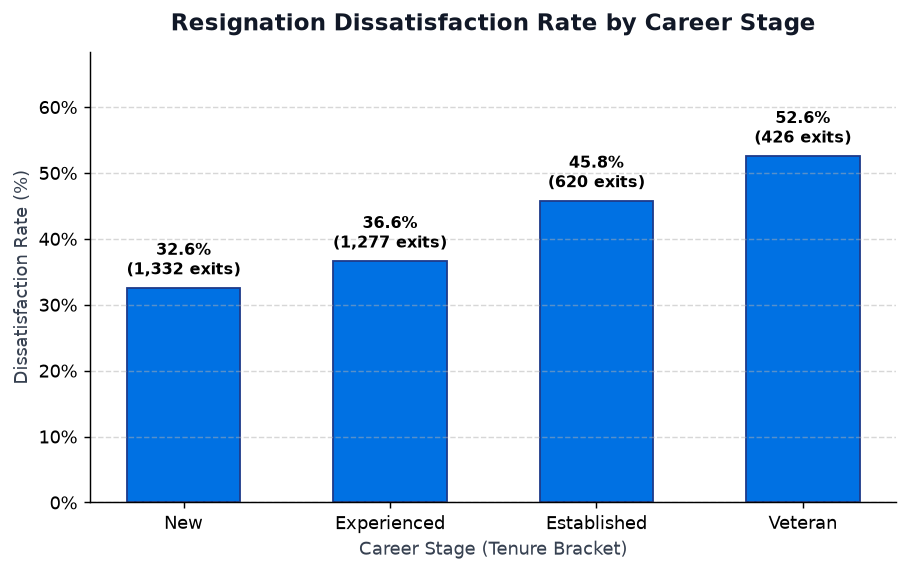

In [8]:
# Calculate dissatisfaction percentage by career stage
order = ['New', 'Experienced', 'Established', 'Veteran']
dissat_by_stage = combined[combined['service_cat'] != 'Unspecified'].groupby('service_cat')['dissatisfied'].mean().reindex(order) * 100
stage_counts = combined[combined['service_cat'] != 'Unspecified']['service_cat'].value_counts().reindex(order)

# Plot Dissatisfaction Rate by Career Stage
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(dissat_by_stage.index, dissat_by_stage.values, color='#0071E3', width=0.55, edgecolor='#1E3A8A', linewidth=1)
ax.set_title("Resignation Dissatisfaction Rate by Career Stage", fontsize=13, pad=12, fontweight='bold', color='#111827')
ax.set_ylabel("Dissatisfaction Rate (%)", fontsize=10, color='#374151')
ax.set_xlabel("Career Stage (Tenure Bracket)", fontsize=10, color='#374151')
ax.set_ylim(0, max(dissat_by_stage.max() * 1.3, 60))
ax.yaxis.set_major_formatter(ticker.PercentFormatter())
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar, count in zip(bars, stage_counts):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 1.2, f"{yval:.1f}%\n({count:,} exits)", ha='center', va='bottom', fontsize=9, fontweight='600')

plt.tight_layout()
plt.show()

### Finding 2: Institutional Disparity (DETE vs. TAFE)
Comparing attrition dissatisfaction drivers between secondary schooling (DETE) and vocational training (TAFE).

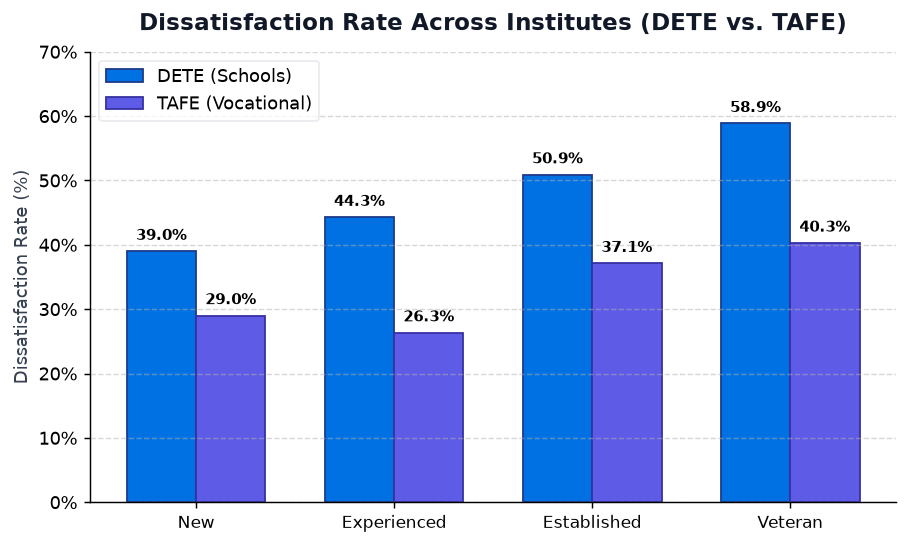

In [9]:
# Institutional comparison across career stages
inst_stage = combined[combined['service_cat'] != 'Unspecified'].groupby(['service_cat', 'institute'])['dissatisfied'].mean().unstack()[['DETE', 'TAFE']].reindex(order) * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(order))
w = 0.35
b_dete = ax.bar(x - w/2, inst_stage['DETE'], w, label='DETE (Schools)', color='#0071E3', edgecolor='#1E3A8A')
b_tafe = ax.bar(x + w/2, inst_stage['TAFE'], w, label='TAFE (Vocational)', color='#5E5CE6', edgecolor='#3730A3')

for b in b_dete:
    h = b.get_height()
    if not np.isnan(h):
        ax.text(b.get_x() + b.get_width()/2, h + 1.2, f"{h:.1f}%", ha='center', va='bottom', fontsize=8.5, fontweight='600')
for b in b_tafe:
    h = b.get_height()
    if not np.isnan(h):
        ax.text(b.get_x() + b.get_width()/2, h + 1.2, f"{h:.1f}%", ha='center', va='bottom', fontsize=8.5, fontweight='600')

ax.set_xticks(x)
ax.set_xticklabels(order, fontsize=9.5)
ax.set_ylabel("Dissatisfaction Rate (%)", fontsize=10, color='#374151')
ax.set_title("Dissatisfaction Rate Across Institutes (DETE vs. TAFE)", fontsize=13, pad=12, fontweight='bold', color='#111827')
ax.set_ylim(0, 70)
ax.yaxis.set_major_formatter(ticker.PercentFormatter())
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(frameon=True, facecolor='#FFFFFF', edgecolor='#E5E7EB')

plt.tight_layout()
plt.show()

### Finding 3: Ranked Departure Friction Factors
Identifying the specific workplace friction elements that prompt employees to voluntarily exit.

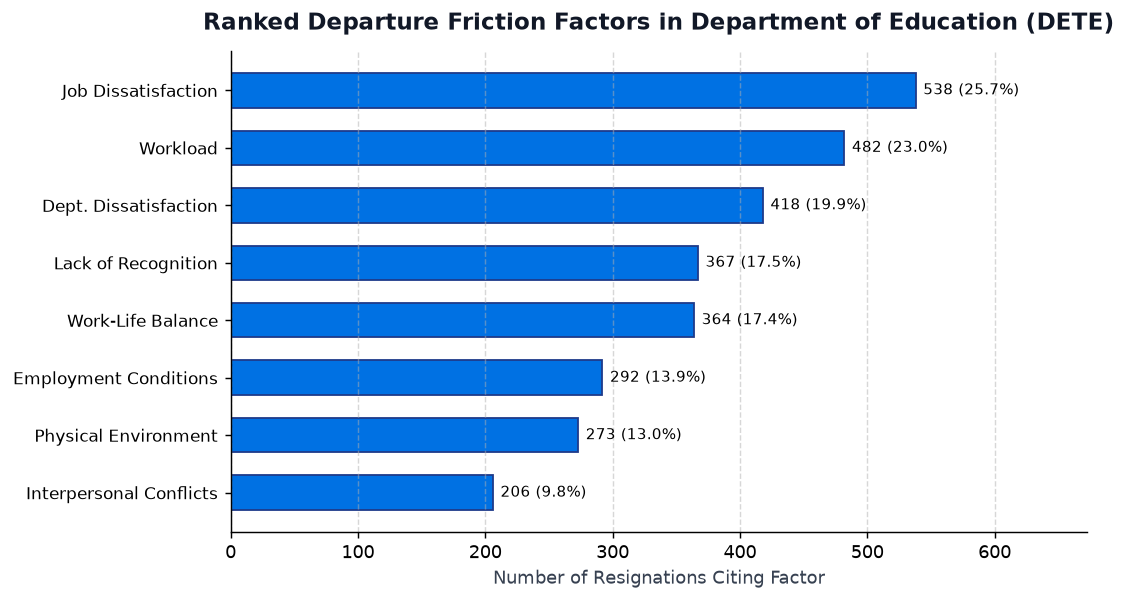

In [10]:
# Ranked friction factors in DETE
s_factors = pd.Series(factor_counts).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
y_ind = np.arange(len(s_factors))
ax.barh(y_ind, s_factors.values, color='#0071E3', height=0.6, edgecolor='#1E3A8A')

for i, (val, name) in enumerate(zip(s_factors.values, s_factors.index)):
    pct = (val / len(dete_resignations)) * 100
    ax.text(val + 2, i, f" {val} ({pct:.1f}%)", va='center', ha='left', fontsize=8.5, fontweight='500')

ax.set_yticks(y_ind)
ax.set_yticklabels(s_factors.index, fontsize=9.5)
ax.set_xlabel("Number of Resignations Citing Factor", fontsize=10, color='#374151')
ax.set_title("Ranked Departure Friction Factors in Department of Education (DETE)", fontsize=12.5, pad=12, fontweight='bold', color='#111827')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_xlim(0, max(s_factors.values) * 1.25)

plt.tight_layout()
plt.show()

### Key Analytical Findings & Takeaways
1. **Tenure Vulnerability:** Dissatisfaction rates scale directly with tenure length. Early-career employees with under 3 years of service usually leave for external opportunities, reporting a 32.6% dissatisfaction rate. In contrast, veteran staff with 11 or more years of service reach a 52.6% dissatisfaction rate, with over half citing job dissatisfaction, workload fatigue, or management friction.
2. **Institutional Disparity:** DETE staff report higher dissatisfaction overall (46.5%) compared to TAFE staff (30.2%), driven by heavier workloads and administrative pressure in primary and secondary school environments.
3. **Leading Friction Drivers:** General job dissatisfaction, external career moves, and workload fatigue are the top reasons staff give when leaving both institutions.